In [1]:
from datasets import load_dataset
imdb_dataset= load_dataset("stanfordnlp/imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [2]:
import random
from collections import Counter
from typing import List, Tuple
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, Dataset

In [3]:
SEED = 42
EMBED_DIM = 100
WINDOW_SIZE = 2
NEGATIVE_SAMPLES = 5
BATCH_SIZE = 512
EPOCHS = 5
LR = 0.002 # learning rate
NUM_DOCUMENTS = 100 # 읽을 문서 수
DEVICE = torch.device("cuda" if torch.cuda.is_available() else
"cpu")

In [4]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

# **문서를 단어 단위로 쪼개기**

In [5]:
def read_corpus() -> List[List[str]]:
    imdb_dataset = load_dataset("stanfordnlp/imdb")
    files: List[str] = imdb_dataset["train"]["text"][:NUM_DOCUMENTS]
    print(f"files_example = {files[1]}")
    # return 구문 상세화~
    # output = []
    # for f in files:
    #   f: str
    #   inner_1 = []
    #   for w in f.split():
    #     inner_1.append(w.lower())
    #   output.append(inner_1)
    # files = output
    return [[w.lower() for w in f.split()] for f in files]


tokens_list = read_corpus()
print(f"#(documents): {len(tokens_list)}")
print("The number of tokens in the 1st document:", len(tokens_list[0]))
print(f"imdb_corpus[0][:20] = {tokens_list[0][:20]}")

# 단일 토큰 시퀀스로 flatten
all_tokens: List[str] = [tok for doc in tokens_list for tok in doc]

files_example = "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity. Granted, they only offer some fleeting views, but where are the R-rated films with gaping vulvas and flapping labia? Nowhere, because they don't exist. The same goes for those crappy cable shows: schlongs swinging in the breeze but not a clitoris in sight. And those pretentious indie movies like The Brown Bunny, in which we're treated to the site of Vincent Gallo's throbbing johnson, but not a trace of pink visible on Chloe Sevigny. Before crying (or implying) "double-standard" in matters of nudity, the mentally obtuse should take into account one unavoidably obvious anatomical difference between men and women: there are no genitals on display when actresses appears nude, a

# **vocab생성**

In [6]:
def build_vocab(tokens_list: List[List[str]], tokens: List[str]) -> Tuple[dict,dict, List[List[int]]]:
  word2idx = {}
  idx2word = {}
  i=0
  #word2idx["AAAA"] = 1
  for token in tokens:
    if token not in word2idx:
      word2idx[token] = i
      idx2word[i] = token
      i += 1
  # idx2word = {v: k for k, v in word2idx.items()}
  indexed_docs : list[list[int]] = [[word2idx[token] for token in tokens] for tokens in tokens_list]
  return word2idx, idx2word, indexed_docs

word2idx, idx2word, indexed_docs = build_vocab(tokens_list, all_tokens)
vocab_size = len(word2idx)
print(f"어휘 수: {vocab_size}")
print(indexed_docs[0][:20])

어휘 수: 6008
[0, 1, 0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 15, 17]


# **pair 생성**

In [7]:
def build_skipgram_pairs_docs(indexed_docs: list[list[int]], window_size:int =2) -> list[Tuple[int, int]]:
  output = []
  print("idx in doc :", indexed_docs[0])
  for doc in  indexed_docs:
    for c_i , c in enumerate(doc):
      left = max(0,c_i - window_size)
      right = min(c_i + window_size, len(doc) - 1)
      for j in range(left, right + 1):
        if j != c_i:
          output.append((c, doc[j]))
  return output

pairs = build_skipgram_pairs_docs(indexed_docs, window_size=1)
print(pairs[:10])

idx in doc : [0, 1, 0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 15, 17, 18, 19, 20, 21, 0, 22, 23, 13, 24, 18, 15, 17, 25, 26, 27, 28, 29, 15, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 9, 40, 41, 42, 0, 43, 44, 32, 45, 34, 46, 47, 48, 49, 50, 51, 52, 53, 38, 54, 55, 56, 57, 58, 59, 60, 61, 32, 62, 63, 64, 65, 66, 67, 20, 68, 64, 61, 32, 69, 70, 71, 32, 72, 73, 74, 9, 75, 76, 77, 11, 78, 79, 80, 66, 81, 82, 83, 84, 85, 11, 86, 87, 88, 89, 83, 20, 11, 90, 91, 20, 92, 93, 94, 88, 95, 96, 9, 97, 66, 98, 99, 76, 100, 64, 101, 102, 103, 70, 56, 104, 105, 88, 106, 107, 48, 108, 109, 110, 66, 0, 2, 3, 51, 13, 111, 112, 113, 34, 17, 41, 114, 115, 11, 102, 88, 116, 117, 118, 119, 88, 120, 121, 122, 123, 124, 125, 126, 127, 73, 128, 129, 130, 131, 5, 132, 133, 134, 15, 135, 20, 136, 102, 88, 116, 118, 38, 137, 138, 20, 55, 139, 122, 140, 141, 142, 98, 143, 32, 144, 145, 146, 147, 148, 44, 102, 117, 20, 149, 150, 48, 151, 152, 153, 11, 154, 46, 11, 155, 13, 156, 102, 157, 20, 11, 158, 51,

# **스무딩해서 단어 별 확률 분표 표시**

In [8]:
def make_unigram_probs(indexed_docs:list[list[int]], vocab_size: int, power: float= 0.75) -> np.ndarray:
    freqs= np.zeros(vocab_size, dtype=np.float64)
    for doc in indexed_docs:
        for i in doc:
          freqs[i] += 1

    probs= freqs**power
    probs/=probs.sum()
    return probs

probs = make_unigram_probs(indexed_docs,vocab_size)
print("단어별 확률 분포:")
for i, p in enumerate(probs):
    print(f"단어 {i}: {p:.4f}")

print("\n확률의 합:", probs.sum())

단어별 확률 분포:
단어 0: 0.0058
단어 1: 0.0001
단어 2: 0.0006
단어 3: 0.0002
단어 4: 0.0019
단어 5: 0.0012
단어 6: 0.0006
단어 7: 0.0002
단어 8: 0.0013
단어 9: 0.0098
단어 10: 0.0022
단어 11: 0.0173
단어 12: 0.0001
단어 13: 0.0049
단어 14: 0.0001
단어 15: 0.0053
단어 16: 0.0018
단어 17: 0.0047
단어 18: 0.0006
단어 19: 0.0003
단어 20: 0.0073
단어 21: 0.0001
단어 22: 0.0010
단어 23: 0.0001
단어 24: 0.0024
단어 25: 0.0001
단어 26: 0.0023
단어 27: 0.0002
단어 28: 0.0001
단어 29: 0.0021
단어 30: 0.0008
단어 31: 0.0002
단어 32: 0.0095
단어 33: 0.0001
단어 34: 0.0057
단어 35: 0.0001
단어 36: 0.0001
단어 37: 0.0008
단어 38: 0.0108
단어 39: 0.0003
단어 40: 0.0012
단어 41: 0.0001
단어 42: 0.0001
단어 43: 0.0016
단어 44: 0.0014
단어 45: 0.0014
단어 46: 0.0042
단어 47: 0.0001
단어 48: 0.0046
단어 49: 0.0013
단어 50: 0.0009
단어 51: 0.0072
단어 52: 0.0001
단어 53: 0.0007
단어 54: 0.0005
단어 55: 0.0002
단어 56: 0.0001
단어 57: 0.0001
단어 58: 0.0003
단어 59: 0.0001
단어 60: 0.0025
단어 61: 0.0003
단어 62: 0.0002
단어 63: 0.0002
단어 64: 0.0013
단어 65: 0.0014
단어 66: 0.0020
단어 67: 0.0003
단어 68: 0.0002
단어 69: 0.0002
단어 70: 0.0024
단어 71

In [9]:
class SkipGramDataset(Dataset):
    def __init__(self, pairs: List[Tuple[int, int]], probs: np.ndarray, vocab_size: int, k: int):
      self.pairs= pairs
      self.probs= probs
      self.vocab_size= vocab_size
      self.k= k

    def __len__(self):
      return len(self.pairs)

    def __getitem__(self, idx):

        center, pos= self.pairs[idx]

        negs= np.random.choice(self.vocab_size, size=self.k, replace=True, p=self.probs)

        return(
        torch.tensor(center),
        torch.tensor(pos),
        torch.tensor(negs),
        )

In [13]:
dataset= SkipGramDataset(pairs, probs, vocab_size, NEGATIVE_SAMPLES)
print(f"Thefirst example: {dataset[1]}")

Thefirst example: (tensor(1), tensor(0), tensor([ 122,  402, 1496,  959,  362]))


# *Skip-gram 모델 도입*

In [20]:
class SkipGramNS(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int):
        super().__init__()
        self.embed_dim = embed_dim
        self.in_embed = nn.Embedding(vocab_size, embed_dim)
        self.out_embed = nn.Embedding(vocab_size, embed_dim)
        nn.init.uniform_(self.in_embed.weight, a=-0.5/embed_dim, b=0.5/embed_dim)
        nn.init.uniform_(self.out_embed.weight, a=-0.5/embed_dim, b=0.5/embed_dim)

    def forward(self, cent, pos, neg):
      # B: mini-batch size, K: #(negative samples), D: self.embed_dim
      # cent: (B), pos: (B), neg: (B, K)
      cent= self.in_embed(cent) # (B, D)
      pos= self.in_embed(pos) # (B, D)
      neg= self.in_embed(neg) # (B, K, D)
      pos_mult= (cent* pos) # (B, D)
      pos_inner= pos_mult.sum(dim=-1) # (B)
      cent_2= cent.reshape(-1, 1, self.embed_dim) # (B, 1, D)
      neg_mult= cent_2* neg# (B, K, D)
      neg_inner= neg_mult.sum(dim=-1) # (B, K)
      pos_loss= -nn.functional.logsigmoid(pos_inner) # (B)
      neg_loss= -nn.functional.logsigmoid(-neg_inner).sum(dim=-1) # (B)
      return (pos_loss+neg_loss).mean()

    def get_input_embeddings(self):
      return self.in_embed.weight.detach().cpu().numpy()


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
model = SkipGramNS(vocab_size, EMBED_DIM)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# **visualize_embeddings 추가**

[Epoch 1] mean loss: 4.1529
[Epoch 2] mean loss: 4.1156
[Epoch 3] mean loss: 4.0838
[Epoch 4] mean loss: 4.0581
[Epoch 5] mean loss: 4.0349


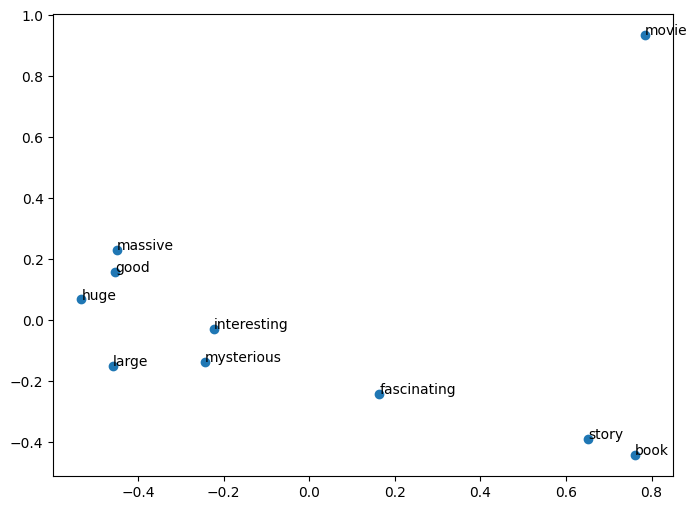

In [23]:
def train(selected_words: List[str]):
  loader= DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
  model= SkipGramNS(vocab_size, EMBED_DIM).to(DEVICE)
  optim= torch.optim.Adam(model.parameters(), lr=LR)
  model.train()
  for epoch in range(1, EPOCHS+ 1):
    epoch_loss= 0.0
    for center, pos, neg in loader:
        center, pos, neg= center.to(DEVICE), pos.to(DEVICE), neg.to(DEVICE)
        loss= model(center, pos, neg)
        loss.backward()
        optim.step()
        optim.zero_grad()
        epoch_loss+= loss.item()
    print(f"[Epoch {epoch}] mean loss: {epoch_loss/ len(loader):.4f}")

  embeds= model.get_input_embeddings()
  visualize_embeddings(embeds, idx2word, selected_words)

def visualize_embeddings(
embeds: np.ndarray, idx2word: dict, selected_words: List[str],
save_path="pca.png"
):
    word2idx= {w: i for i, w in idx2word.items()}
    words_vis: List[str] = [w for w in selected_words if w in word2idx]
    idxs= [ word2idx[w] for w in words_vis]
    X= embeds[idxs]
    pca= PCA(n_components=2, random_state=SEED)
    X2= pca.fit_transform(X)
    plt.figure(figsize=(8, 6))
    plt.scatter(X2[:, 0], X2[:, 1])
    for i, w in enumerate(words_vis):
        plt.annotate(w, (X2[i, 0], X2[i, 1]), fontsize=10)
    plt.savefig(save_path)
    plt.show()


if __name__== "__main__":
    train(['movie', 'book', 'mysterious', 'story', 'fascinating',
    'good', 'interesting', 'large', 'massive', 'huge'])

# **메인 루프**

In [ ]:

def train(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for i, (cent, pos, neg) in enumerate(dataloader):
        cent, pos, neg = cent.to(device), pos.to(device), neg.to(device)

        optimizer.zero_grad()
        loss = model(cent, pos, neg)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(f"  [Batch {i+1}/{len(dataloader)}] Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    return avg_loss



@torch.no_grad()
def test(model, dataloader, device, idx2word):
    model.eval()
    embeddings = model.in_embed.weight.detach().cpu().numpy()

    # 단순히 시각화를 위해 가장 유사한 단어 5개 출력 (테스트 역할)
    def most_similar(word, topn=5):
        if word not in word2idx:
            print(f"'{word}' is not in vocabulary.")
            return []
        idx = word2idx[word]
        vec = embeddings[idx]
        sims = np.dot(embeddings, vec) / (
            np.linalg.norm(embeddings, axis=1) * np.linalg.norm(vec)
        )
        best = np.argsort(-sims)[1 : topn + 1]
        return [(idx2word[i], float(sims[i])) for i in best]

    print("\n [테스트] 예시 단어 유사도")
    for w in ["good", "bad", "movie", "love"]:
        print(f"Top similar to '{w}': {most_similar(w)}")


def main():
    print("\n시작")
    model.to(DEVICE)

    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    for epoch in range(1, EPOCHS + 1):
        avg_loss = train(model, dataloader, optimizer, DEVICE)
        print(f"Epoch [{epoch}/{EPOCHS}] ▶ 평균 손실: {avg_loss:.4f}")

    # 훈련 종료 후 테스트
    test(model, dataloader, DEVICE, idx2word)

    # 모델 저장
    torch.save(model.state_dict(), "skipgram_imdb.pth")
    print("\n모델이 'skipgram_imdb.pth'로 저장")


if __name__ == "__main__":
    main()



시작
Epoch [1/5] ▶ 평균 손실: 4.0708
Epoch [2/5] ▶ 평균 손실: 4.0568
Epoch [3/5] ▶ 평균 손실: 4.0432
Epoch [4/5] ▶ 평균 손실: 4.0379
Epoch [5/5] ▶ 평균 손실: 4.0229

 [테스트] 예시 단어 유사도
Top similar to 'good': [('studly', 0.8418915271759033), ('smart-mouthed', 0.8329722285270691), ('condensed', 0.8210389614105225), ('bit', 0.8117253184318542), ('troubled', 0.7980466485023499)]
Top similar to 'bad': [('taste', 0.812875509262085), ('t.v.', 0.7015591263771057), ('move', 0.658294141292572), ("one--that's", 0.6195735931396484), ('so', 0.6009122729301453)]
Top similar to 'movie': [('film', 0.841873049736023), ('entire', 0.8082484006881714), ('plays', 0.768360435962677), ('future.', 0.761469304561615), ('gigglesome', 0.7590161561965942)]
Top similar to 'love': [('violence', 0.7701368927955627), ('coincidences,', 0.7563748359680176), ('premiere', 0.7498736381530762), ('diminishes', 0.736452579498291), ('presidential', 0.7361940741539001)]

모델이 'skipgram_imdb.pth'로 저장
